In [50]:
#SETUP 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [5]:
# Importing Data 


df = pd.read_csv("hf://datasets/processvenue/SARCASM_VS_NON_SARCASM/PROJ_SARCASM_VS_NON_SARCASM_6000_0004(HF).csv")

/Users/felipe/Documents/BSE/Term-3/advanced_nlp/sarcasm_text_classification/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Manual data exploration

## Columns types and Initial exploration

Few things to consider on first EDA, setences are really human written-like, and there spacing and graphic erros that we might need to consider, specially in preprocessing 

example 1:
'fantasy,fairy tale, wild imagination, adsurd...'

example 2


In [45]:
print("--Data Loaded COLUMNS---")
print(df.columns)

print("--Data Loaded HEAD---")
print(df.head())


print("--Data Loaded INFO---")
print(df.info())

# Sanity checks
print("--Data Loaded checking duplicated---")
print(df.duplicated().sum())
print("--Data Loaded checking unique values---")
print(df.Sentence.duplicated().sum())

#we do have duplicated setences, let's check them closely
print("--Data Loaded checking duplicated sentences---")
print(df[df.Sentence.duplicated(keep=False)].sort_values(by="Sentence"))
#in any of the have different labels?
print("--Data Loaded checking labels for duplicated sentences---")
print(df[df.Sentence.duplicated(keep=False)].groupby("Sentence").agg(lambda x: x.unique().tolist()))

print("--Data Loaded checking null values---")
print(df.isnull().sum())

--Data Loaded COLUMNS---
Index(['S.No', 'Sentence', 'Annotator 1', 'Annotator 2', 'IAA'], dtype='str')
--Data Loaded HEAD---
   S.No                                           Sentence    Annotator 1  \
0     1  with such eloquent and compelling arguments as...      Sarcastic   
1     2  fantasy,fairy tale, wild imagination, adsurd ,...  Non-Sarcastic   
2     3  'if carrying guns became legal, then police co...      Sarcastic   
3     4  It was a troll. Now that we've activated email...      Sarcastic   
4     5  Poor little poopie. \r\nIf your gay sex agenda...      Sarcastic   

     Annotator 2       IAA  
0      Sarcastic     Agree  
1  Non-Sarcastic     Agree  
2      Sarcastic     Agree  
3  Non-Sarcastic  Disagree  
4      Sarcastic     Agree  
--Data Loaded INFO---
<class 'pandas.DataFrame'>
Index: 5702 entries, 0 to 5939
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   S.No         5702 non-null   int64
 1   S

### Handling duplicated sentences

In [46]:
#Getting one manual example of a sentence to check if the labels are correct
df[df.Sentence.str.contains("Life threatening condition that is always phys")]

# We can see that the same annotator changed their mind about the label of the sentence, which is a bit concerning, so we are drpopping the duplicated sentences to avoid confusion in the model training, and we will remove them totally, not keeping any of them, as we don't know which one is correct, and we don't want to introduce noise in the model training by keeping one of them.
df_n_duplicated = df[~df.duplicated(subset="Sentence", keep=False)].copy()

#cheking duplicated sentences after filtering
print("--Data Loaded checking duplicated sentences after filtering---")
print(df_n_duplicated[df_n_duplicated.Sentence.duplicated(keep=False)].sort_values(by="Sentence"))

--Data Loaded checking duplicated sentences after filtering---
Empty DataFrame
Columns: [S.No, Sentence, Annotator 1, Annotator 2, IAA]
Index: []


## Numerical exploration

### First Step, agreements and distribution 

We do have more sarcastic examples than non-sarcastic examples, but the difference is not huge. This is good for training a model, as it will not be too biased towards one class.

In [47]:
#distribution of agreements
print("--Distribution of agreements---")
print(df_n_duplicated['IAA'].value_counts())


#For those where they disagree, what is the distribution of both annotators (is there any possibility of bias)?
print("--Distribution of annotators for disagreements---")
print(df_n_duplicated[df_n_duplicated['IAA'] == "Disagree"]['Annotator 1'].value_counts())
print(df_n_duplicated[df_n_duplicated['IAA'] == "Disagree"]['Annotator 2'].value_counts())
#annotator 1 Is a bit more likely to label as sarcastic than annotator 2, but the difference is not huge.

print("--Distribution of labels (WHEN THEY AGREE)---")
print(df_n_duplicated[df_n_duplicated['IAA'] == "Agree"]['Annotator 1'].value_counts())
#in percentage terms
print("--Distribution of labels (WHEN THEY AGREE) in percentage---")
print(df_n_duplicated[df_n_duplicated['IAA'] == "Agree"]['Annotator 1'].value_counts(normalize=True))

--Distribution of agreements---
IAA
Agree       3634
Disagree    2068
Name: count, dtype: int64
--Distribution of annotators for disagreements---
Annotator 1
Sarcastic        1091
Non-Sarcastic     977
Name: count, dtype: int64
Annotator 2
Non-Sarcastic    1091
Sarcastic         977
Name: count, dtype: int64
--Distribution of labels (WHEN THEY AGREE)---
Annotator 1
Sarcastic        2283
Non-Sarcastic    1351
Name: count, dtype: int64
--Distribution of labels (WHEN THEY AGREE) in percentage---
Annotator 1
Sarcastic        0.628233
Non-Sarcastic    0.371767
Name: proportion, dtype: float64


### Second Step, do we have any other correlation with sarcasm or with disagreement?

Here, we gonna test if sarcasm is correlated with number of tokens, or tokens size, for example. The initial Hypothis here is that usually longer setencers are less sarcastic, and also more difficult to agree on.  


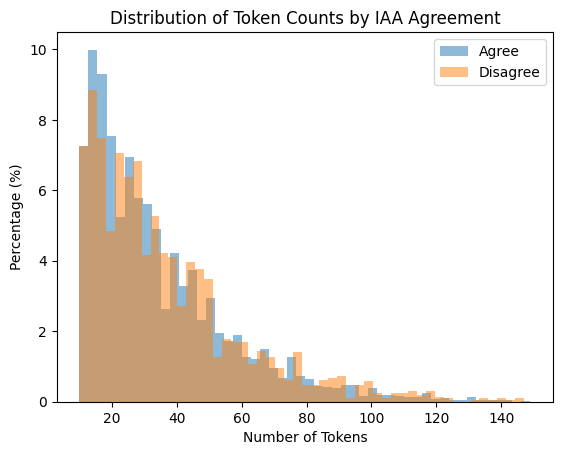

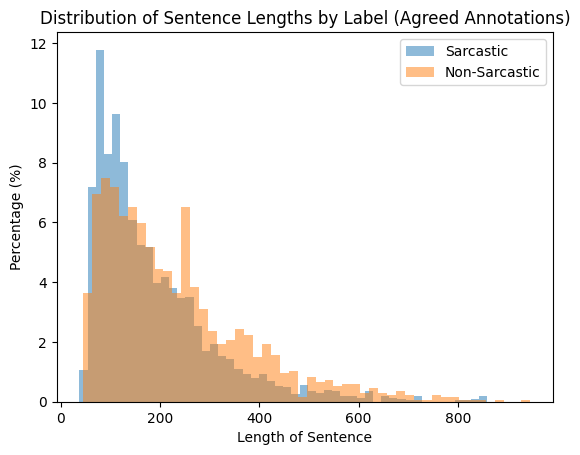

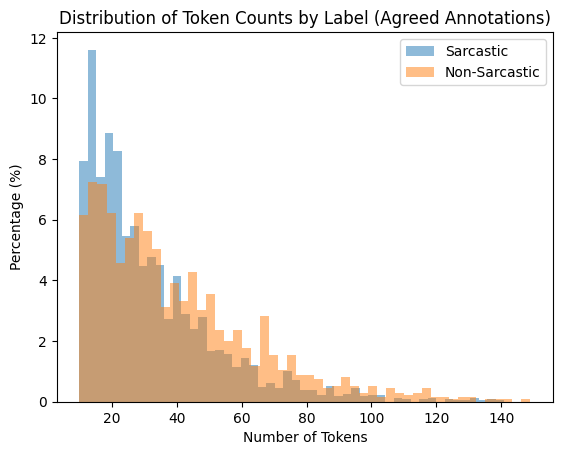

In [53]:
# Distribution of token counts by IAA (Agree vs Disagree)
agree_lengths = df_n_duplicated[df_n_duplicated['IAA'] == "Agree"].Sentence.str.split().str.len()
disagree_lengths = df_n_duplicated[df_n_duplicated['IAA'] == "Disagree"].Sentence.str.split().str.len()

plt.hist(agree_lengths, bins=50, alpha=0.5, label="Agree",
         weights=np.ones(len(agree_lengths)) / len(agree_lengths) * 100)
plt.hist(disagree_lengths, bins=50, alpha=0.5, label="Disagree",
         weights=np.ones(len(disagree_lengths)) / len(disagree_lengths) * 100)

plt.title("Distribution of Token Counts by IAA Agreement")
plt.xlabel("Number of Tokens")
plt.ylabel("Percentage (%)")
plt.legend()
plt.show()



# Distribution of sentence lengths by label in percentage terms only for those where they agree
df_filtered = df_n_duplicated[df_n_duplicated['IAA'] == "Agree"].copy()

sarcastic_lengths = df_filtered[df_filtered['Annotator 1'] == "Sarcastic"].Sentence.str.len()
non_sarcastic_lengths = df_filtered[df_filtered['Annotator 1'] == "Non-Sarcastic"].Sentence.str.len()

plt.hist(sarcastic_lengths, bins=50, alpha=0.5, label="Sarcastic",
         weights=np.ones(len(sarcastic_lengths)) / len(sarcastic_lengths) * 100)
plt.hist(non_sarcastic_lengths, bins=50, alpha=0.5, label="Non-Sarcastic",
         weights=np.ones(len(non_sarcastic_lengths)) / len(non_sarcastic_lengths) * 100)

plt.title("Distribution of Sentence Lengths by Label (Agreed Annotations)")
plt.xlabel("Length of Sentence")
plt.ylabel("Percentage (%)")
plt.legend()
plt.show()


# Distribution of sentence lengths by label in percentage terms only for those where they agree
sarcastic_lengths = df_filtered[df_filtered['Annotator 1'] == "Sarcastic"].Sentence.str.split().str.len()
non_sarcastic_lengths = df_filtered[df_filtered['Annotator 1'] == "Non-Sarcastic"].Sentence.str.split().str.len()

plt.hist(sarcastic_lengths, bins=50, alpha=0.5, label="Sarcastic",
         weights=np.ones(len(sarcastic_lengths)) / len(sarcastic_lengths) * 100)
plt.hist(non_sarcastic_lengths, bins=50, alpha=0.5, label="Non-Sarcastic",
         weights=np.ones(len(non_sarcastic_lengths)) / len(non_sarcastic_lengths) * 100)

plt.title("Distribution of Token Counts by Label (Agreed Annotations)")
plt.xlabel("Number of Tokens")
plt.ylabel("Percentage (%)")
plt.legend()
plt.show()

Here We can see that usually non-sarcastic setences are a little bit longer (in the median), but the agreemenet doesn't seems to have a clear correlation in between them 